# Core Deep Learning Architectures for Time Series

**Docker image**: `ml4t-gpu`

This notebook compares foundational neural network architectures for return
prediction: MLP, 1D-CNN, LSTM, and GRU. We evaluate training efficiency versus
predictive accuracy on pooled single-ETF sequences to understand the tradeoffs
that motivated newer architectures like N-BEATS and Transformers.

**Learning Objectives**:
- Implement MLP, CNN, LSTM, and GRU forecasting models in PyTorch
- Compare training time versus predictive accuracy (Spearman IC)
- Demonstrate LSTM's sequential bottleneck via sequence-length scaling
- Establish baselines for comparison with modern architectures

**Book Reference**: Chapter 13, Section 13.1 (The Recurrent Paradigm and Its Discontents).
See Hochreiter and Schmidhuber (1997) for the original LSTM formulation.

**Prerequisites**: ETF price data (via `load_etfs()` canonical loader)

In [1]:
"""Core Deep Learning Architectures — compare MLP, CNN, LSTM, and GRU for return prediction."""

import time
import warnings
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import torch
import torch.nn as nn
from ml4t.diagnostic.metrics import cross_sectional_ic_series

from data import load_etfs
from utils.reproducibility import set_global_seeds

warnings.filterwarnings("ignore")

In [2]:
SEED = 42
LOOKBACK = 60
HORIZON = 1
HIDDEN_SIZE = 64
EPOCHS = 50
BATCH_SIZE = 32
SYMBOLS = ["SPY", "QQQ", "IWM", "EFA", "EEM", "TLT", "GLD", "USO"]
START_DATE = "2015-01-01"
LOOKBACKS = [30, 60, 120, 240]

In [3]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

set_global_seeds(SEED)

Using device: cuda


## Data Acquisition

We use ETF close prices from the case study pipeline, converting to daily returns.
Eight ETFs span equities, bonds, commodities, and international markets. The
architecture comparison pools univariate sequences from all eight ETFs so the
result is not driven by one SPY-only split.

In [4]:
etf_df = load_etfs()

start_dt = datetime.fromisoformat(START_DATE)

close_wide = (
    etf_df.filter(pl.col("symbol").is_in(SYMBOLS) & (pl.col("timestamp") >= start_dt))
    .pivot(on="symbol", values="close", index="timestamp")
    .drop_nulls()
    .sort("timestamp")
)

feature_cols = [c for c in close_wide.columns if c != "timestamp"]
returns = close_wide.with_columns(
    [pl.col(c).pct_change().alias(c) for c in feature_cols]
).drop_nulls()

print(f"Data: {returns.shape[0]} days, {len(feature_cols)} ETFs")
print(f"Date range: {returns['timestamp'][0]} to {returns['timestamp'][-1]}")

Data: 2765 days, 8 ETFs
Date range: 2015-01-05 to 2025-12-31


## Sequence Construction

Each input is a lookback window of daily returns for one ETF. The target is the
ETF's **next-day return** — a deliberately noisy single-step objective aligned with
the direct return-prediction tasks used throughout the book. Pooling sequences from
all eight ETFs ensures the result is not driven by one symbol's split.

### Univariate sequence builder

Slides a `lookback`-length window over one ETF's return series and pairs each
window with the realised return `horizon` steps ahead.

In [5]:
def create_sequences(data: np.ndarray, lookback: int, horizon: int):
    """Create univariate input sequences with next-horizon return targets."""
    X, y = [], []
    for i in range(len(data) - lookback - horizon + 1):
        X.append(data[i : i + lookback])
        y.append(data[i + lookback + horizon - 1])
    return np.array(X), np.array(y)

### Panel pooling and chronological split

Applies the per-symbol builder to each ETF, splits 80/20 in calendar order, and
records the target date and symbol for every test sample so cross-sectional IC
can be evaluated across symbols on each date.

In [6]:
def create_panel_sequences(
    returns_df: pl.DataFrame,
    symbols: list[str],
    lookback: int,
    horizon: int,
    split_fraction: float = 0.8,
):
    """Create chronological train/test splits for each ETF, then pool samples."""
    timestamps = returns_df["timestamp"].to_numpy()
    train_X, train_y, test_X, test_y = [], [], [], []
    test_dates_list, test_symbols_list = [], []
    for symbol in symbols:
        series = returns_df[symbol].to_numpy()
        X_symbol, y_symbol = create_sequences(series, lookback, horizon)
        split_idx = int(len(X_symbol) * split_fraction)
        train_X.append(X_symbol[:split_idx])
        train_y.append(y_symbol[:split_idx])
        test_X.append(X_symbol[split_idx:])
        test_y.append(y_symbol[split_idx:])
        n_test = len(X_symbol) - split_idx
        target_offsets = np.arange(n_test) + split_idx + lookback + horizon - 1
        test_dates_list.append(timestamps[target_offsets])
        test_symbols_list.append(np.full(n_test, symbol))
    return (
        np.concatenate(train_X),
        np.concatenate(train_y),
        np.concatenate(test_X),
        np.concatenate(test_y),
        np.concatenate(test_dates_list),
        np.concatenate(test_symbols_list),
    )

### Cross-sectional IC helper

Computes the mean cross-sectional Spearman rank correlation between predicted
and realised returns across symbols at each date, then averages over dates.
`min_obs=5` keeps dates with as few as 5 ETFs out of 8 — the library default of
10 would discard every date in this 8-symbol panel.

In [7]:
def cross_sectional_ic_mean(y_true, y_pred, dates, symbols):
    """Mean cross-sectional Spearman IC across dates."""
    pred_df = pl.DataFrame({"timestamp": dates, "symbol": symbols, "prediction": y_pred})
    ret_df = pl.DataFrame({"timestamp": dates, "symbol": symbols, "forward_return": y_true})
    ic_per_date = cross_sectional_ic_series(
        pred_df,
        ret_df,
        pred_col="prediction",
        ret_col="forward_return",
        date_col="timestamp",
        entity_col="symbol",
        min_obs=5,
    )
    ic_clean = ic_per_date.drop_nulls("ic")
    return float(ic_clean["ic"].mean()) if ic_clean.height else float("nan")

In [8]:
X_train, y_train, X_test, y_test, test_dates, test_symbols = create_panel_sequences(
    returns, SYMBOLS, LOOKBACK, HORIZON
)

X_train_t = torch.FloatTensor(X_train).unsqueeze(-1).to(DEVICE)
y_train_t = torch.FloatTensor(y_train).unsqueeze(-1).to(DEVICE)
X_test_t = torch.FloatTensor(X_test).unsqueeze(-1).to(DEVICE)
y_test_t = torch.FloatTensor(y_test).unsqueeze(-1).to(DEVICE)

print(
    f"Pooled ETF sequences: X_train {X_train.shape}, X_test {X_test.shape} "
    f"| Train: {len(X_train)}, Test: {len(X_test)}"
)

Pooled ETF sequences: X_train (17312, 60), X_test (4328, 60) | Train: 17312, Test: 4328


## Model Definitions

Four architectures with comparable parameter counts for fair comparison.
The MLP flattens the sequence; the CNN applies same-padded temporal
convolutions over the lookback window (no look-ahead, but the right half of
the kernel is padded rather than masked — see `05_tcn` for a strictly causal
variant); the LSTM and GRU process steps sequentially — the key bottleneck
discussed in Section 13.1.

### MLP Baseline

Flattens the lookback window into a single vector. Fully parallel — no
sequential dependency between time steps.

In [9]:
class MLPForecaster(nn.Module):
    def __init__(self, lookback: int, hidden_size: int):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(lookback, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        return self.fc3(x)

### 1D-CNN

Applies convolutions along the time axis. Captures local patterns within the
kernel window and processes all positions in parallel.

In [10]:
class CNNForecaster(nn.Module):
    def __init__(self, lookback: int, hidden_size: int):
        super().__init__()
        self.conv1 = nn.Conv1d(1, hidden_size // 2, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(hidden_size // 2, hidden_size, kernel_size=3, padding=1)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(hidden_size, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        x = self.pool(x).squeeze(-1)
        return self.fc(x)

### LSTM

The hidden state at time $t$ depends on $t{-}1$, creating $O(T)$ sequential
computation. This is the bottleneck discussed in Section 13.1 — the architecture
cannot leverage GPU parallelism across time steps.

In [11]:
class LSTMForecaster(nn.Module):
    def __init__(self, hidden_size: int, num_layers: int = 2):
        super().__init__()
        self.lstm = nn.LSTM(1, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        return self.fc(lstm_out[:, -1, :])

### GRU

The Gated Recurrent Unit merges the LSTM's forget and input gates into a single
update gate, reducing parameter count. It shares the same $O(T)$ sequential
dependency but trains faster on smaller datasets due to fewer parameters.

In [12]:
class GRUForecaster(nn.Module):
    def __init__(self, hidden_size: int, num_layers: int = 2):
        super().__init__()
        self.gru = nn.GRU(1, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        gru_out, _ = self.gru(x)
        return self.fc(gru_out[:, -1, :])

## Training Loop

In [13]:
def train_model(model, X_train, y_train, epochs, batch_size, model_name):
    """Train a model and return training time and loss history."""
    model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.MSELoss()
    n_samples = len(X_train)
    loss_history = []
    start_time = time.time()
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0
        n_batches = 0
        indices = torch.randperm(n_samples, device=DEVICE)
        for i in range(0, n_samples, batch_size):
            batch_idx = indices[i : i + batch_size]
            optimizer.zero_grad()
            predictions = model(X_train[batch_idx])
            loss = criterion(predictions, y_train[batch_idx])
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            n_batches += 1
        avg_loss = epoch_loss / n_batches
        loss_history.append(avg_loss)
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"{model_name} Epoch {epoch + 1}/{epochs}: Loss = {avg_loss:.6f}")
    return time.time() - start_time, loss_history

## Model Comparison

Train all four architectures on the same data and compare efficiency versus accuracy.

In [14]:
models = {
    "MLP": MLPForecaster(LOOKBACK, HIDDEN_SIZE),
    "CNN": CNNForecaster(LOOKBACK, HIDDEN_SIZE),
    "LSTM": LSTMForecaster(HIDDEN_SIZE),
    "GRU": GRUForecaster(HIDDEN_SIZE),
}

results = {}

for name, model in models.items():
    n_params = sum(p.numel() for p in model.parameters())
    print(f"\nTraining {name} ({n_params:,} parameters)...")

    train_time, loss_history = train_model(model, X_train_t, y_train_t, EPOCHS, BATCH_SIZE, name)

    model.eval()
    with torch.no_grad():
        predictions = model(X_test_t).cpu().numpy().flatten()
        actuals = y_test_t.cpu().numpy().flatten()

    mse = float(np.mean((predictions - actuals) ** 2))
    ic = cross_sectional_ic_mean(actuals, predictions, test_dates, test_symbols)

    results[name] = {
        "train_time": train_time,
        "mse": mse,
        "ic": ic,
        "n_params": n_params,
        "loss_history": loss_history,
    }


Training MLP (8,129 parameters)...


MLP Epoch 1/50: Loss = 0.000214


MLP Epoch 10/50: Loss = 0.000160


MLP Epoch 20/50: Loss = 0.000131


MLP Epoch 30/50: Loss = 0.000116


...

GRU Epoch 10/50: Loss = 0.000211


GRU Epoch 20/50: Loss = 0.000210


GRU Epoch 30/50: Loss = 0.000209


GRU Epoch 40/50: Loss = 0.000208


GRU Epoch 50/50: Loss = 0.000207


## Results Summary

In [15]:
comparison_df = pl.DataFrame(
    [
        {
            "Model": name,
            "Parameters": r["n_params"],
            "Train Time (s)": round(r["train_time"], 2),
            "Test MSE": round(r["mse"], 6),
            "Spearman IC": round(r["ic"], 4),
        }
        for name, r in results.items()
    ]
)
comparison_df

Model,Parameters,Train Time (s),Test MSE,Spearman IC
str,i64,f64,f64,f64
"""MLP""",8129,14.3,0.000199,0.0008
"""CNN""",6401,18.32,0.000147,NaN
"""LSTM""",50497,28.01,0.00015,-0.0076
"""GRU""",37889,26.12,0.000151,0.0005


**Interpretation**: The table illustrates the sequential bottleneck — LSTM and
GRU training require recurrent updates, while MLP and CNN process the sequence in
parallel. The next-day return target is noisy, so small IC differences should not
be over-interpreted. The point is the efficiency-accuracy tradeoff, not model
selection for a production strategy.

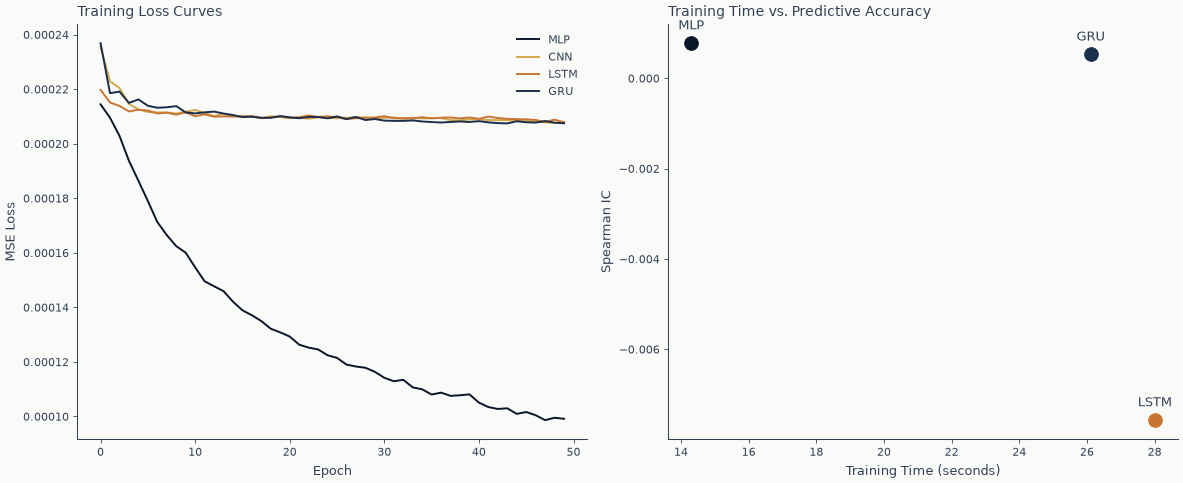

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: Training loss curves
for name, r in results.items():
    axes[0].plot(r["loss_history"], label=name)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE Loss")
axes[0].set_title("Training Loss Curves")
axes[0].legend()

# Right: Training time vs. IC scatter
for name, r in results.items():
    axes[1].scatter(r["train_time"], r["ic"], s=100, zorder=5)
    axes[1].annotate(
        name,
        (r["train_time"], r["ic"]),
        textcoords="offset points",
        xytext=(0, 10),
        ha="center",
    )
axes[1].set_xlabel("Training Time (seconds)")
axes[1].set_ylabel("Spearman IC")
axes[1].set_title("Training Time vs. Predictive Accuracy")

fig.tight_layout()
fig.show()

**Finding**: The efficiency–accuracy scatter shows diminishing returns from
sequential processing. The LSTM's training time is substantially higher than the
MLP's, but the IC improvement (if any) is modest. This motivates the search for
architectures that achieve comparable accuracy with parallel computation.

## Sequence-Length Scaling

The LSTM's $O(T)$ sequential dependency means training time grows with sequence
length, while the MLP processes any length in parallel (flattened).
This experiment trains both at increasing lookback windows to measure the
divergence — the core limitation discussed in Section 13.1.

In [17]:
lookbacks = LOOKBACKS

scaling_results = {}

for lb in lookbacks:
    X_tr_np, y_tr_np, X_te_np, y_te_np, test_dates_lb, test_symbols_lb = create_panel_sequences(
        returns, SYMBOLS, lb, HORIZON
    )

    X_tr = torch.FloatTensor(X_tr_np).unsqueeze(-1).to(DEVICE)
    y_tr = torch.FloatTensor(y_tr_np).unsqueeze(-1).to(DEVICE)
    X_te = torch.FloatTensor(X_te_np).unsqueeze(-1).to(DEVICE)
    y_te = torch.FloatTensor(y_te_np).unsqueeze(-1).to(DEVICE)

    for arch_name, ModelCls, kwargs in [
        ("MLP", MLPForecaster, {"lookback": lb, "hidden_size": HIDDEN_SIZE}),
        ("LSTM", LSTMForecaster, {"hidden_size": HIDDEN_SIZE}),
    ]:
        model = ModelCls(**kwargs)
        t, _ = train_model(model, X_tr, y_tr, EPOCHS, BATCH_SIZE, f"{arch_name}-{lb}")

        model.eval()
        with torch.no_grad():
            preds = model(X_te).cpu().numpy().flatten()
            acts = y_te.cpu().numpy().flatten()
        ic_val = cross_sectional_ic_mean(acts, preds, test_dates_lb, test_symbols_lb)

        scaling_results[(arch_name, lb)] = {"time": t, "ic": ic_val}

MLP-30 Epoch 1/50: Loss = 0.000220


MLP-30 Epoch 10/50: Loss = 0.000173


MLP-30 Epoch 20/50: Loss = 0.000154


MLP-30 Epoch 30/50: Loss = 0.000145


MLP-30 Epoch 40/50: Loss = 0.000135


...

LSTM-240 Epoch 10/50: Loss = 0.000212


LSTM-240 Epoch 20/50: Loss = 0.000212


LSTM-240 Epoch 30/50: Loss = 0.000211


LSTM-240 Epoch 40/50: Loss = 0.000211


LSTM-240 Epoch 50/50: Loss = 0.000211


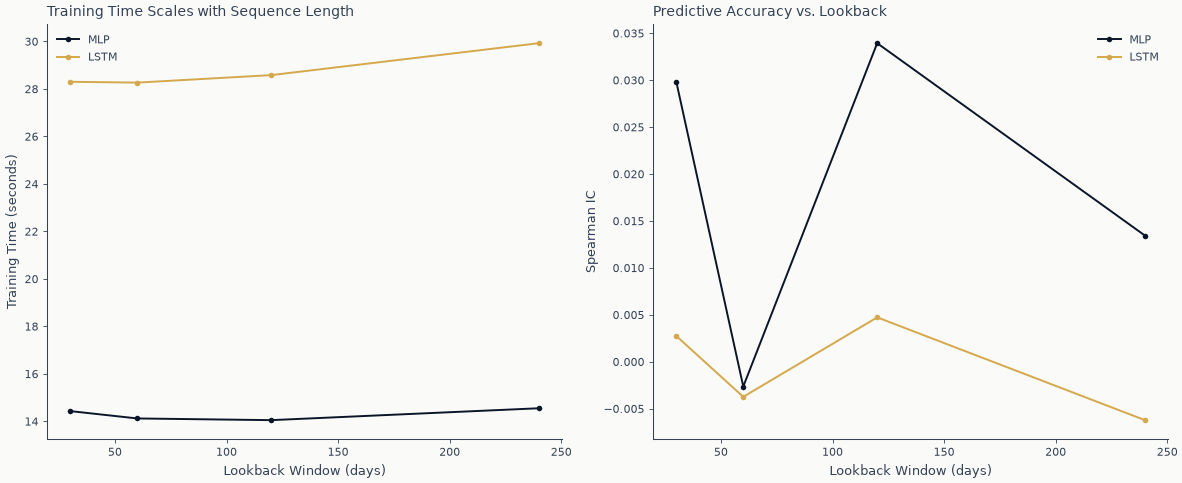

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for arch in ["MLP", "LSTM"]:
    lbs = [lb for lb in lookbacks if (arch, lb) in scaling_results]
    times = [scaling_results[(arch, lb)]["time"] for lb in lbs]
    ics = [scaling_results[(arch, lb)]["ic"] for lb in lbs]

    axes[0].plot(lbs, times, "o-", label=arch)
    axes[1].plot(lbs, ics, "o-", label=arch)

axes[0].set_xlabel("Lookback Window (days)")
axes[0].set_ylabel("Training Time (seconds)")
axes[0].set_title("Training Time Scales with Sequence Length")
axes[0].legend()

axes[1].set_xlabel("Lookback Window (days)")
axes[1].set_ylabel("Spearman IC")
axes[1].set_title("Predictive Accuracy vs. Lookback")
axes[1].legend()

fig.tight_layout()
fig.show()

**Finding**: LSTM training time rises more quickly with lookback length, while
the MLP is less sequentially constrained because it flattens longer windows
into a larger input vector — wall-clock growth comes from the larger first-layer
matmul, not from $O(T)$ recurrence. The IC plot is noisy, reinforcing that this
notebook is an architecture demonstration rather than a validated trading model.

**Limitation**: This uses a single 80/20 temporal split, not walk-forward
validation. Section 13.7 covers proper evaluation methodology.

## sktime Alternative

High-level APIs like sktime wrap these architectures in a unified
`fit()`/`predict()` interface, reducing the training loop above to a few lines.
This is useful for rapid prototyping before committing to a custom implementation.

**Dependency note**: sktime's neural forecasters require `neuralforecast`, which
depends on `ray` — and ray does not yet support Python 3.14
([ray-project/ray#56434](https://github.com/ray-project/ray/issues/56434)).
Once ray adds 3.14 wheels, run `uv pip install neuralforecast` and uncomment
the sktime demo cell below.

In [19]:
# import pandas as pd
# from sktime.forecasting.neuralforecast import NeuralForecastLSTM
#
# symbol = SYMBOLS[0]
# spy_prices = close_wide.select(["timestamp", symbol]).to_pandas()
# spy_prices = spy_prices.set_index("timestamp")[symbol].dropna()
#
# split = int(len(spy_prices) * 0.8)
# y_train_sk = spy_prices.iloc[:split]
# y_test_sk = spy_prices.iloc[split : split + HORIZON]
#
# forecaster = NeuralForecastLSTM(
#     freq="B",
#     input_size=LOOKBACK,
#     max_steps=EPOCHS * 5,
#     encoder_hidden_size=HIDDEN_SIZE,
# )
# forecaster.fit(y_train_sk)
# y_pred_sk = forecaster.predict(fh=list(range(1, HORIZON + 1)))
#
# mae_sk = float(np.mean(np.abs(y_test_sk.values - y_pred_sk.values)))
# print(f"sktime NeuralForecastLSTM MAE: {mae_sk:.4f}")

## Key Takeaways

1. **The objective is deliberately simple and noisy**: pooled univariate ETF
   sequences predict next-day returns, so modest IC values are expected.
2. **Parallel architectures train efficiently** because the MLP and CNN can process
   all time steps simultaneously, while recurrent models update hidden state
   sequentially.
3. **Small IC differences are not model-selection evidence** in this single
   illustrative split. Case-study notebooks use walk-forward validation and richer
   feature sets for publication-grade comparisons.
4. **Sequence-length scaling** confirms the $O(T)$ bottleneck: LSTM training time
   grows linearly with lookback, while the MLP is less sequentially constrained
   (its growth comes from a larger first-layer matmul, not recurrence).
5. These tradeoffs motivated N-BEATS (parallelizable decomposition) and Transformers
   (parallelizable attention), explored in subsequent notebooks.

**Next**: See `02_nbeats_interpretable` for the N-BEATS decomposition approach.